In [1]:
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

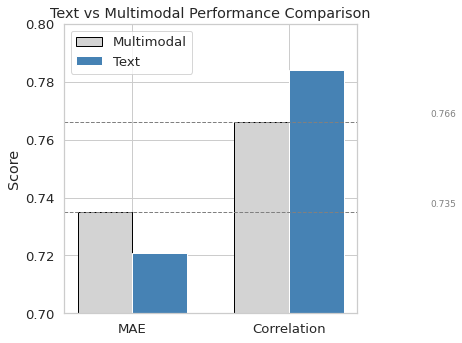

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ['MAE', 'Correlation']
text_values = [0.721, 0.784]
multi_values = [0.735, 0.766]

# Set up plot
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

# Plot bars
bar1 = ax.bar(x - width/2, multi_values, width, label='Multimodal', color='lightgray', edgecolor='black')
bar2 = ax.bar(x + width/2, text_values, width, label='Text', color='steelblue')

# Add dashed horizontal lines for Multimodal values
for i, mv in enumerate(multi_values):
    ax.axhline(y=mv, linestyle='--', color='gray', linewidth=1)
    ax.text(len(metrics)-0.1, mv + 0.002, f'{mv:.3f}', color='gray', fontsize=9)

# Formatting
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 0.8)
ax.set_title('Text vs Multimodal Performance Comparison')
ax.legend()

plt.tight_layout()
plt.show()


# MOSI error_kl vs kl_joint

In [2]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl', 'kl_joint']

In [3]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=['kl_text', 'kl_audio', 'kl_video'], 
                          var_name="KL_Type", 
                          value_name="KL_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'KL_Type'])['KL_Value'].describe()


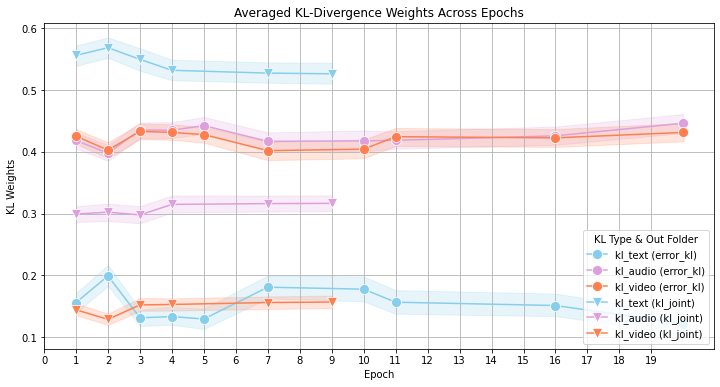

In [4]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'error_kl': 'o', 'kl_joint': 'v'}
modality_colors = {'kl_text': 'skyblue', 'kl_audio': 'plum', 'kl_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["KL_Type"] == modality)], 
            x="epoch", 
            y="KL_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.xticks(np.arange(0, 20, step=1))
plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("KL Weights")
plt.legend(title="KL Type & Out Folder", loc='best')
plt.grid()
plt.show()

# MOSI error_kl vs error_kl_mi

In [5]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl', 'error_kl_mi']

In [6]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "error_kl":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight Video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

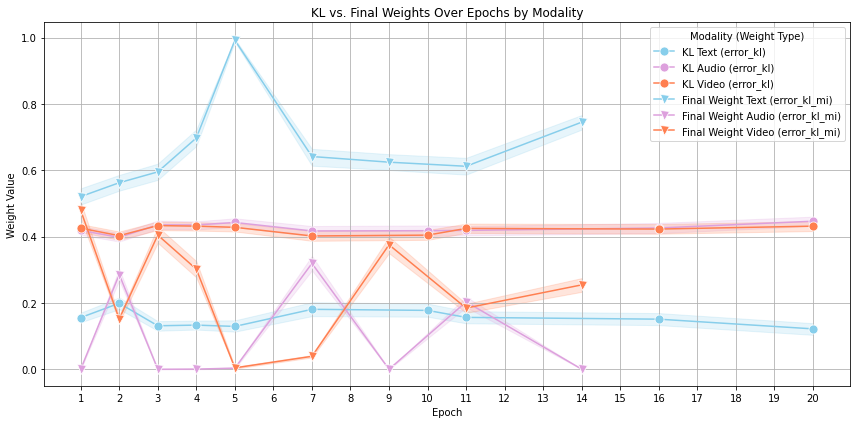

In [7]:
plt.figure(figsize=(12, 6))

# Define color for each modality
modality_colors = {
    "KL Text": "skyblue",
    "KL Audio": "plum",
    "KL Video": "coral",
    "Final Weight Text": "skyblue",
    "Final Weight Audio": "plum",
    "Final Weight Video": "coral"
}

# Marker style for each experiment type
marker_map = {
    "error_kl": "o",     # for KL weights
    "error_kl_mi": "v"         # for Final weights (you can add more folders if needed)
}

# Plot each line
for out_folder in df_weights["out_folder"].unique():
    for weight_type in df_weights["Weight_Type"].unique():
        if weight_type.startswith("KL") and out_folder != "error_kl":
            continue  # Skip KL lines for non-KL experiments
        if weight_type.startswith("Final") and out_folder != "error_kl_mi":
            continue  # Skip Final weights for non-Final experiments

        subset = df_weights[
            (df_weights["out_folder"] == out_folder) &
            (df_weights["Weight_Type"] == weight_type)
        ]

        sns.lineplot(
            data=subset,
            x="epoch", y="Weight_Value",
            label=f"{weight_type} ({out_folder})",
            color=modality_colors[weight_type],
            marker=marker_map[out_folder],
            markersize=9
        )

plt.xticks(np.arange(df_weights["epoch"].min(), df_weights["epoch"].max() + 1, step=1))
plt.title("KL vs. Final Weights Over Epochs by Modality")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Modality (Weight Type)", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# MOSI error_kl vs error_kl_CC

In [2]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl', 'error_kl_cc']

In [4]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "error_kl":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight Video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

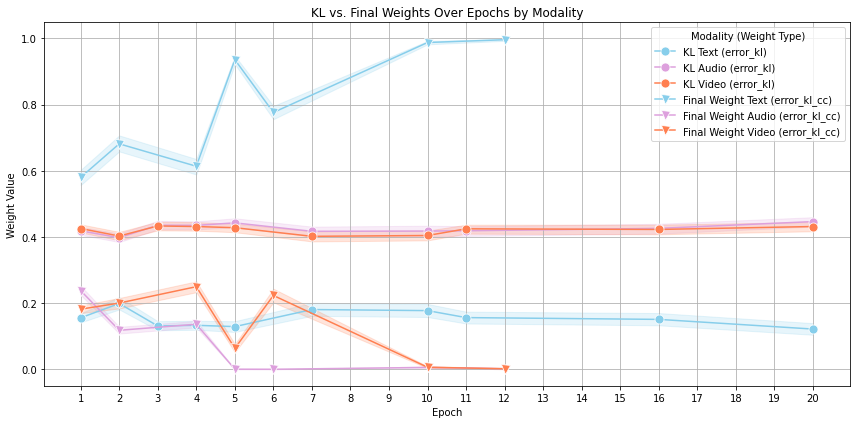

In [5]:
plt.figure(figsize=(12, 6))

# Define color for each modality
modality_colors = {
    "KL Text": "skyblue",
    "KL Audio": "plum",
    "KL Video": "coral",
    "Final Weight Text": "skyblue",
    "Final Weight Audio": "plum",
    "Final Weight Video": "coral"
}

# Marker style for each experiment type
marker_map = {
    "error_kl": "o",     # for KL weights
    "error_kl_cc": "v"         # for Final weights (you can add more folders if needed)
}

# Plot each line
for out_folder in df_weights["out_folder"].unique():
    for weight_type in df_weights["Weight_Type"].unique():
        if weight_type.startswith("KL") and out_folder != "error_kl":
            continue  # Skip KL lines for non-KL experiments
        if weight_type.startswith("Final") and out_folder != "error_kl_cc":
            continue  # Skip Final weights for non-Final experiments

        subset = df_weights[
            (df_weights["out_folder"] == out_folder) &
            (df_weights["Weight_Type"] == weight_type)
        ]

        sns.lineplot(
            data=subset,
            x="epoch", y="Weight_Value",
            label=f"{weight_type} ({out_folder})",
            color=modality_colors[weight_type],
            marker=marker_map[out_folder],
            markersize=9
        )

plt.xticks(np.arange(df_weights["epoch"].min(), df_weights["epoch"].max() + 1, step=1))
plt.title("KL vs. Final Weights Over Epochs by Modality")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Modality (Weight Type)", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# MOSI error_kl_mi vs error_kl_cc

In [6]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl_mi', 'error_kl_cc']

In [7]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                          var_name="Weights_Type", 
                          value_name="Weights_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'Weights_Type'])['Weights_Value'].describe()


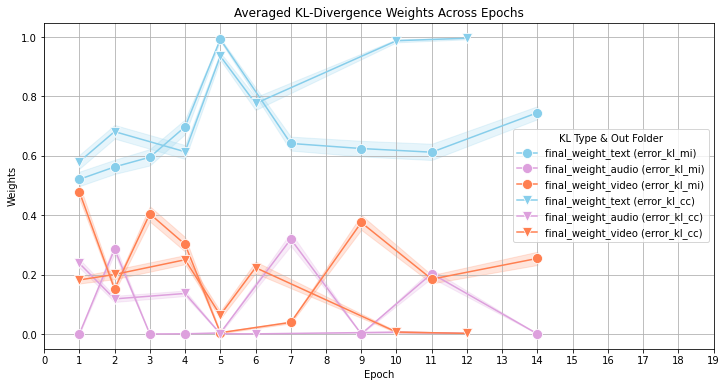

In [8]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'error_kl_mi': 'o', 'error_kl_cc': 'v'}
modality_colors = {'final_weight_text': 'skyblue', 'final_weight_audio': 'plum', 'final_weight_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["Weights_Type"] == modality)], 
            x="epoch", 
            y="Weights_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.xticks(np.arange(0, 20, step=1))
plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weights")
plt.legend(title="KL Type & Out Folder", loc='best')
plt.grid()
plt.show()

# MOSI kl_joint vs kl_joint_mi

In [8]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['kl_joint', 'kl_joint_mi']

In [9]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "kl_joint":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight Video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

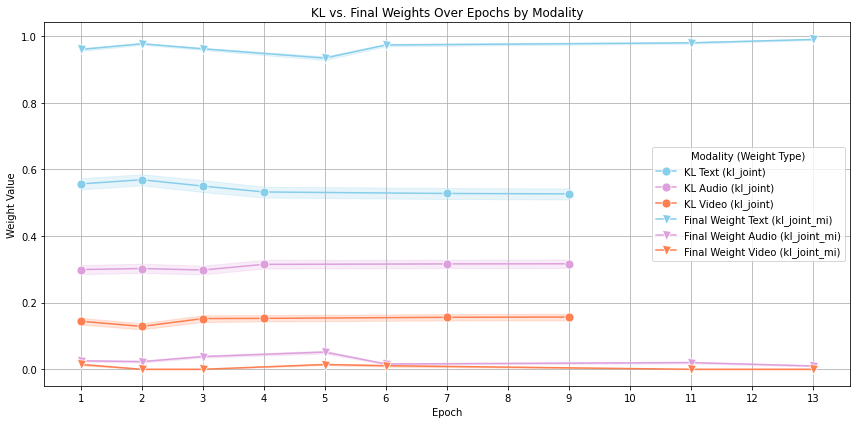

In [10]:
plt.figure(figsize=(12, 6))

# Define color for each modality
modality_colors = {
    "KL Text": "skyblue",
    "KL Audio": "plum",
    "KL Video": "coral",
    "Final Weight Text": "skyblue",
    "Final Weight Audio": "plum",
    "Final Weight Video": "coral"
}

# Marker style for each experiment type
marker_map = {
    "kl_joint": "o",     # for KL weights
    "kl_joint_mi": "v"         # for Final weights (you can add more folders if needed)
}

# Plot each line
for out_folder in df_weights["out_folder"].unique():
    for weight_type in df_weights["Weight_Type"].unique():
        if weight_type.startswith("KL") and out_folder != "kl_joint":
            continue  # Skip KL lines for non-KL experiments
        if weight_type.startswith("Final") and out_folder != "kl_joint_mi":
            continue  # Skip Final weights for non-Final experiments

        subset = df_weights[
            (df_weights["out_folder"] == out_folder) &
            (df_weights["Weight_Type"] == weight_type)
        ]

        sns.lineplot(
            data=subset,
            x="epoch", y="Weight_Value",
            label=f"{weight_type} ({out_folder})",
            color=modality_colors[weight_type],
            marker=marker_map[out_folder],
            markersize=9
        )

plt.xticks(np.arange(df_weights["epoch"].min(), df_weights["epoch"].max() + 1, step=1))
plt.title("KL vs. Final Weights Over Epochs by Modality")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Modality (Weight Type)", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# MOSI error_kl_mi vs kl_joint_mi

In [11]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl_mi', 'kl_joint_mi']

In [12]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                          var_name="KL_MI_Type", 
                          value_name="KL_MI_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'KL_MI_Type'])['KL_MI_Value'].describe()


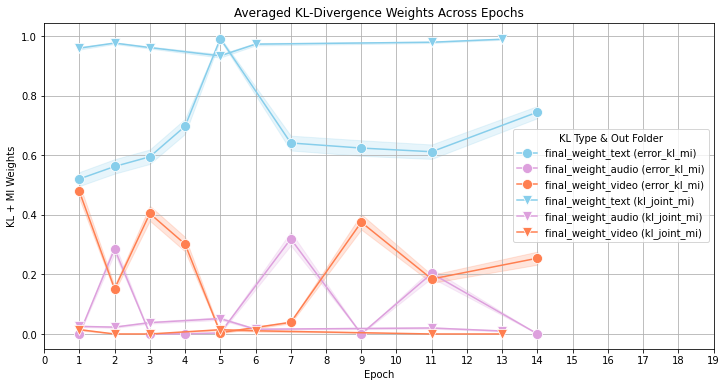

In [13]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'error_kl_mi': 'o', 'kl_joint_mi': 'v'}
modality_colors = {'final_weight_text': 'skyblue', 'final_weight_audio': 'plum', 'final_weight_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["KL_MI_Type"] == modality)], 
            x="epoch", 
            y="KL_MI_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.xticks(np.arange(0, 20, step=1))
plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("KL + MI Weights")
plt.legend(title="KL Type & Out Folder", loc='best')
plt.grid()
plt.show()

# MOSEI error_kl vs kl_joint

In [18]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl', 'kl_joint']

In [19]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosei_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=['kl_text', 'kl_audio', 'kl_video'], 
                          var_name="KL_Type", 
                          value_name="KL_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'KL_Type'])['KL_Value'].describe()


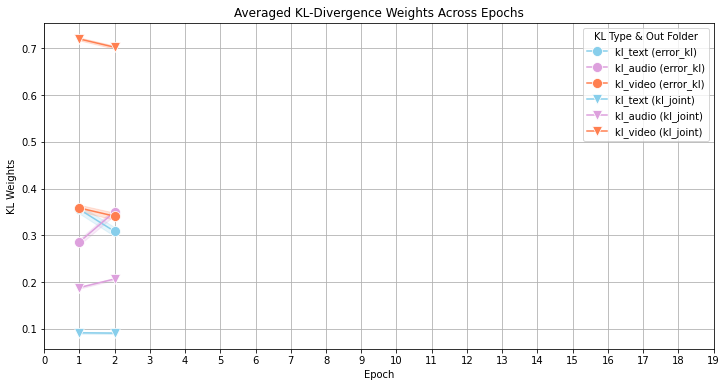

In [20]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'error_kl': 'o', 'kl_joint': 'v'}
modality_colors = {'kl_text': 'skyblue', 'kl_audio': 'plum', 'kl_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["KL_Type"] == modality)], 
            x="epoch", 
            y="KL_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.xticks(np.arange(0, 20, step=1))
plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("KL Weights")
plt.legend(title="KL Type & Out Folder", loc='best')
plt.grid()
plt.show()

# MOSEI error_kl vs error_kl_mi

In [21]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl', 'error_kl_mi']

In [22]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosei_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "error_kl":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight Video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

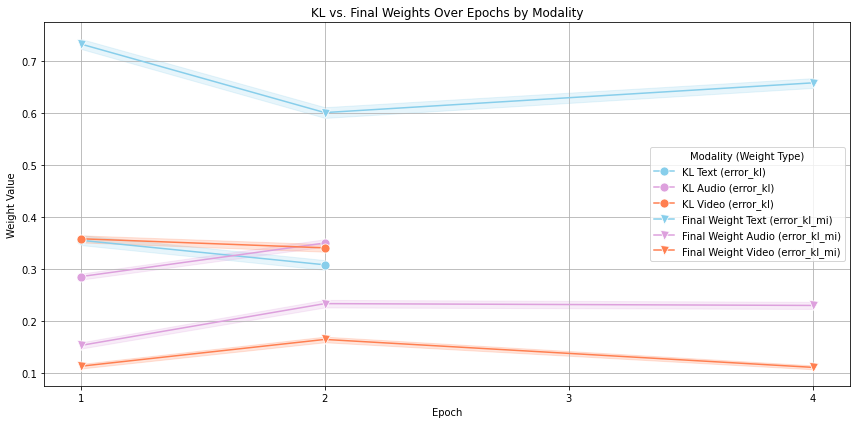

In [23]:
plt.figure(figsize=(12, 6))

# Define color for each modality
modality_colors = {
    "KL Text": "skyblue",
    "KL Audio": "plum",
    "KL Video": "coral",
    "Final Weight Text": "skyblue",
    "Final Weight Audio": "plum",
    "Final Weight Video": "coral"
}

# Marker style for each experiment type
marker_map = {
    "error_kl": "o",     # for KL weights
    "error_kl_mi": "v"         # for Final weights (you can add more folders if needed)
}

# Plot each line
for out_folder in df_weights["out_folder"].unique():
    for weight_type in df_weights["Weight_Type"].unique():
        if weight_type.startswith("KL") and out_folder != "error_kl":
            continue  # Skip KL lines for non-KL experiments
        if weight_type.startswith("Final") and out_folder != "error_kl_mi":
            continue  # Skip Final weights for non-Final experiments

        subset = df_weights[
            (df_weights["out_folder"] == out_folder) &
            (df_weights["Weight_Type"] == weight_type)
        ]

        sns.lineplot(
            data=subset,
            x="epoch", y="Weight_Value",
            label=f"{weight_type} ({out_folder})",
            color=modality_colors[weight_type],
            marker=marker_map[out_folder],
            markersize=9
        )

plt.xticks(np.arange(df_weights["epoch"].min(), df_weights["epoch"].max() + 1, step=1))
plt.title("KL vs. Final Weights Over Epochs by Modality")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Modality (Weight Type)", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# MOSEI error_kl vs error_kl_cc

In [9]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl', 'error_kl_cc']

In [10]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosei_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "error_kl":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight Video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

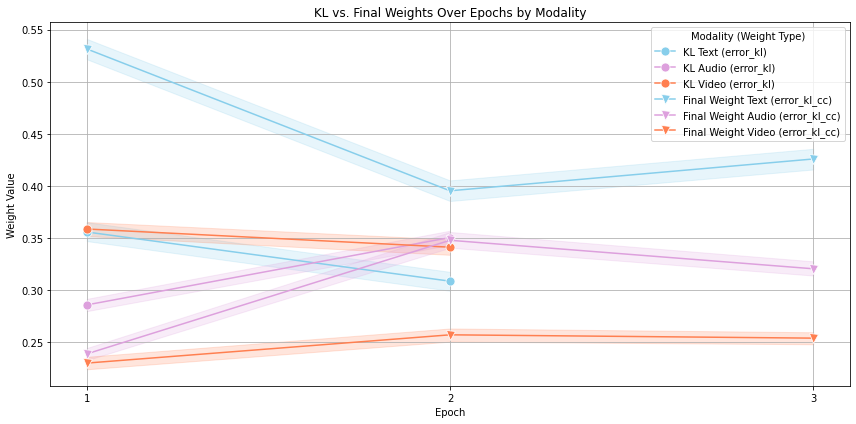

In [11]:
plt.figure(figsize=(12, 6))

# Define color for each modality
modality_colors = {
    "KL Text": "skyblue",
    "KL Audio": "plum",
    "KL Video": "coral",
    "Final Weight Text": "skyblue",
    "Final Weight Audio": "plum",
    "Final Weight Video": "coral"
}

# Marker style for each experiment type
marker_map = {
    "error_kl": "o",     # for KL weights
    "error_kl_cc": "v"         # for Final weights (you can add more folders if needed)
}

# Plot each line
for out_folder in df_weights["out_folder"].unique():
    for weight_type in df_weights["Weight_Type"].unique():
        if weight_type.startswith("KL") and out_folder != "error_kl":
            continue  # Skip KL lines for non-KL experiments
        if weight_type.startswith("Final") and out_folder != "error_kl_cc":
            continue  # Skip Final weights for non-Final experiments

        subset = df_weights[
            (df_weights["out_folder"] == out_folder) &
            (df_weights["Weight_Type"] == weight_type)
        ]

        sns.lineplot(
            data=subset,
            x="epoch", y="Weight_Value",
            label=f"{weight_type} ({out_folder})",
            color=modality_colors[weight_type],
            marker=marker_map[out_folder],
            markersize=9
        )

plt.xticks(np.arange(df_weights["epoch"].min(), df_weights["epoch"].max() + 1, step=1))
plt.title("KL vs. Final Weights Over Epochs by Modality")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Modality (Weight Type)", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# MOSEI error_kl_mi vs error_kl_cc

In [12]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl_mi', 'error_kl_cc']

In [13]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosei_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                          var_name="Weights_Type", 
                          value_name="Weights_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'Weights_Type'])['Weights_Value'].describe()


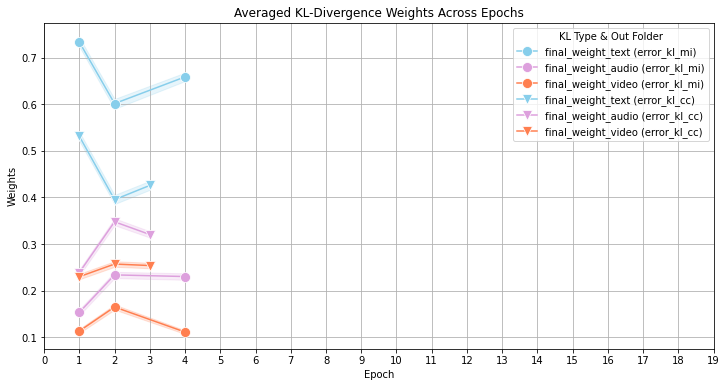

In [14]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'error_kl_mi': 'o', 'error_kl_cc': 'v'}
modality_colors = {'final_weight_text': 'skyblue', 'final_weight_audio': 'plum', 'final_weight_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["Weights_Type"] == modality)], 
            x="epoch", 
            y="Weights_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.xticks(np.arange(0, 20, step=1))
plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weights")
plt.legend(title="KL Type & Out Folder", loc='best')
plt.grid()
plt.show()

# MOSEI kl_joint vs kl_joint_mi

In [24]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['kl_joint', 'kl_joint_mi']

In [25]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosei_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "kl_joint":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight Video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

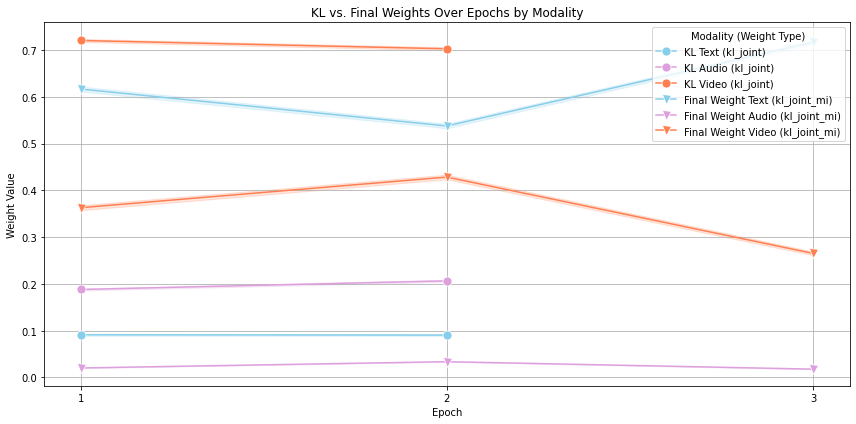

In [26]:
plt.figure(figsize=(12, 6))

# Define color for each modality
modality_colors = {
    "KL Text": "skyblue",
    "KL Audio": "plum",
    "KL Video": "coral",
    "Final Weight Text": "skyblue",
    "Final Weight Audio": "plum",
    "Final Weight Video": "coral"
}

# Marker style for each experiment type
marker_map = {
    "kl_joint": "o",     # for KL weights
    "kl_joint_mi": "v"         # for Final weights (you can add more folders if needed)
}

# Plot each line
for out_folder in df_weights["out_folder"].unique():
    for weight_type in df_weights["Weight_Type"].unique():
        if weight_type.startswith("KL") and out_folder != "kl_joint":
            continue  # Skip KL lines for non-KL experiments
        if weight_type.startswith("Final") and out_folder != "kl_joint_mi":
            continue  # Skip Final weights for non-Final experiments

        subset = df_weights[
            (df_weights["out_folder"] == out_folder) &
            (df_weights["Weight_Type"] == weight_type)
        ]

        sns.lineplot(
            data=subset,
            x="epoch", y="Weight_Value",
            label=f"{weight_type} ({out_folder})",
            color=modality_colors[weight_type],
            marker=marker_map[out_folder],
            markersize=9
        )

plt.xticks(np.arange(df_weights["epoch"].min(), df_weights["epoch"].max() + 1, step=1))
plt.title("KL vs. Final Weights Over Epochs by Modality")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Modality (Weight Type)", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# MOSEI error_kl_mi vs kl_joint_mi

In [27]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/final/"

# Get all available output folders
out_folders = ['error_kl_mi', 'kl_joint_mi']

In [28]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosei_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                          var_name="KL_MI_Type", 
                          value_name="KL_MI_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'KL_MI_Type'])['KL_MI_Value'].describe()


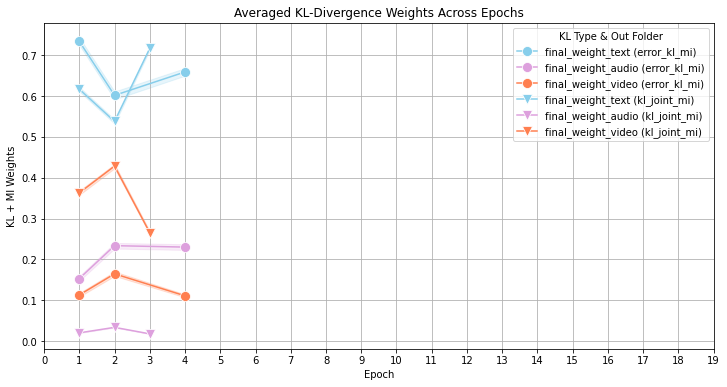

In [29]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'error_kl_mi': 'o', 'kl_joint_mi': 'v'}
modality_colors = {'final_weight_text': 'skyblue', 'final_weight_audio': 'plum', 'final_weight_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["KL_MI_Type"] == modality)], 
            x="epoch", 
            y="KL_MI_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.xticks(np.arange(0, 20, step=1))
plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("KL + MI Weights")
plt.legend(title="KL Type & Out Folder", loc='best')
plt.grid()
plt.show()